In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("/content/diabetes_binary_health_indicators.csv")

In [ ]:
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

### 1. The Crucial First Step: Data Splitting
Your project guidelines emphasize avoiding data leakage by splitting the data before anything else.

In [ ]:
from sklearn.model_selection import train_test_split


# Separate features (X) and target (y)
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


**2. Exploratory Data Analysis (EDA) & Cleaning**

Since there are no missing values, your cleaning will focus on outlier detection (e.g., in continuous variables like BMI). For EDA, the rubric requires unique plots to avoid repetition.

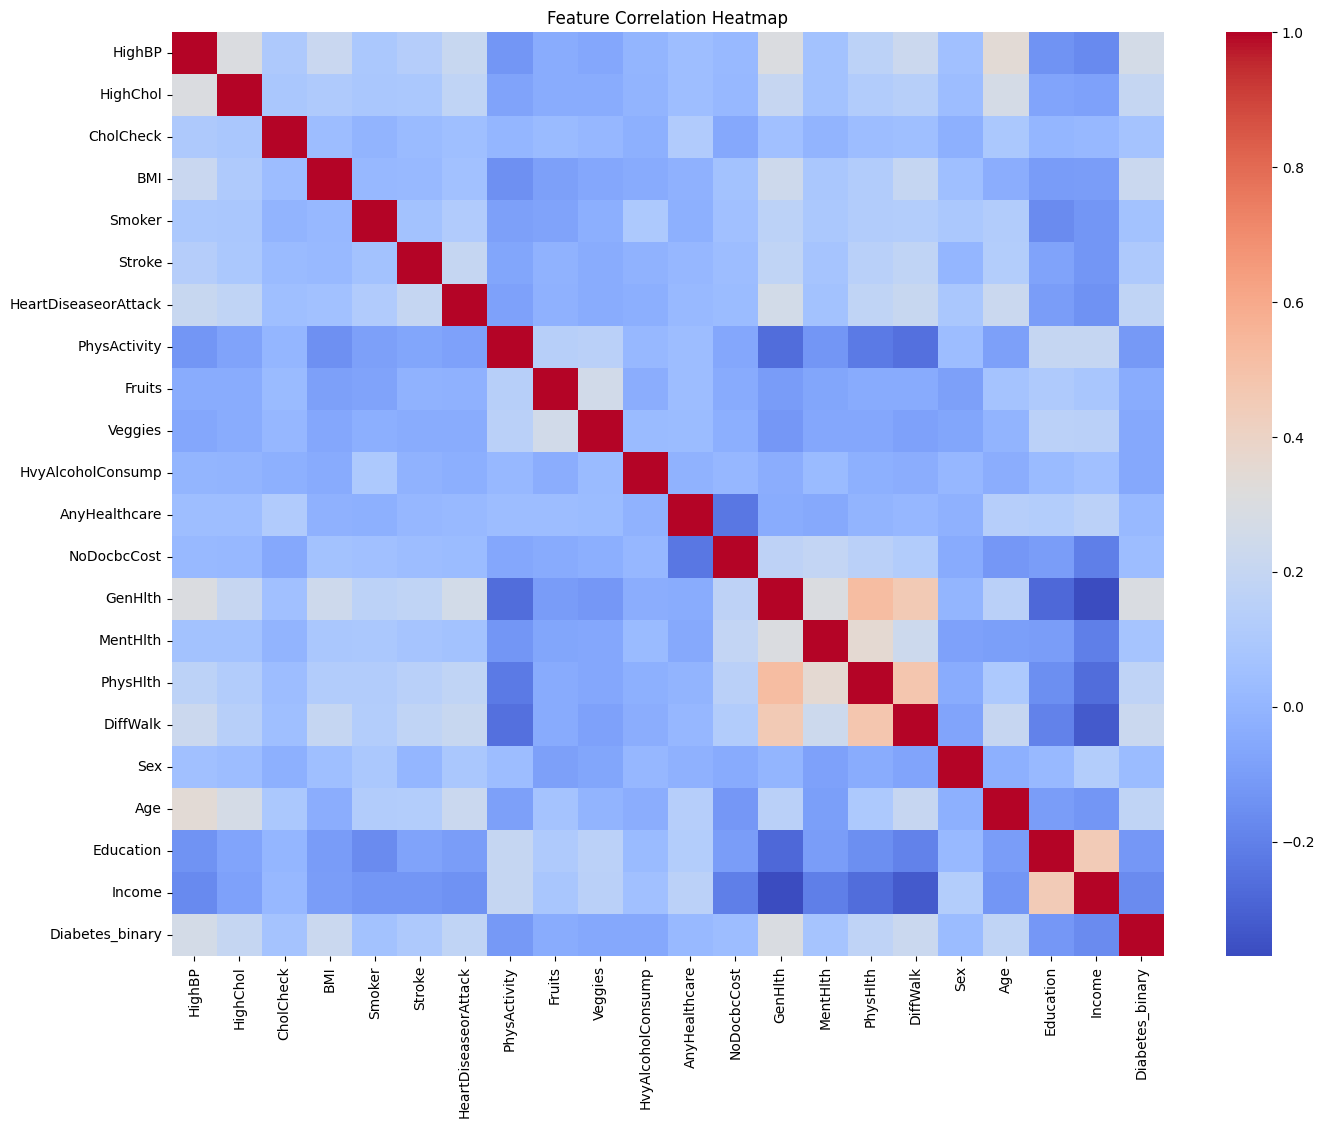

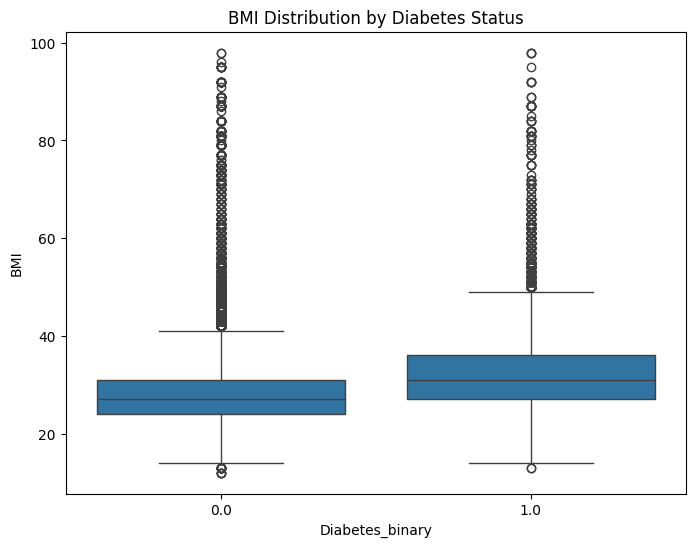

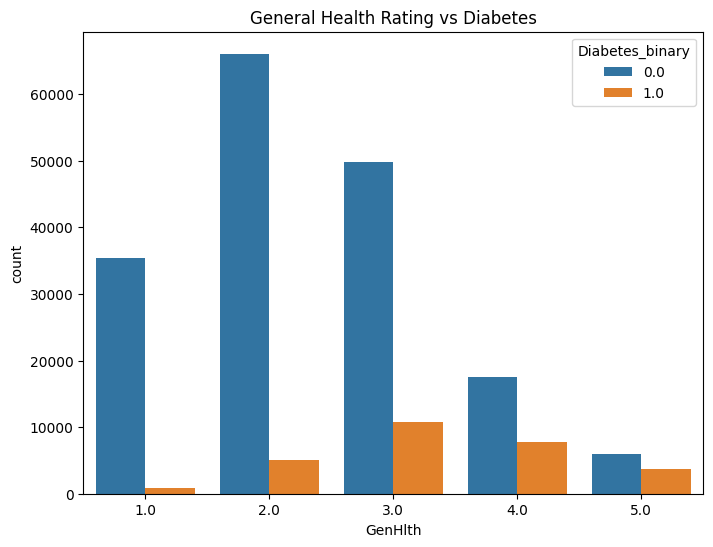

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Correlation Heatmap (To see which features correlate with Diabetes)
plt.figure(figsize=(16, 12))
sns.heatmap(X_train.join(y_train).corr(), annot=False, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

# 2. Boxplot (To visualize the distribution and outliers of a continuous feature)
plt.figure(figsize=(8, 6))
sns.boxplot(x=y_train, y=X_train['BMI'])
plt.title("BMI Distribution by Diabetes Status")
plt.show()

# 3. Countplot (To see categorical relationships)
plt.figure(figsize=(8, 6))
sns.countplot(x=X_train['GenHlth'], hue=y_train)
plt.title("General Health Rating vs Diabetes")
plt.show()

**3. Dimensionality Reduction & SVM Pipeline**

Because SVMs rely heavily on calculating distances between data points, standardizing your features (scaling them to have a mean of 0 and variance of 1) is absolutely mandatory.

We will wrap the scaler, PCA (for dimensionality reduction), and the SVM into a single, clean scikit-learn pipeline.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix

# Build the comprehensive pipeline using LinearSVC
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),       # Step 1: Scale features
    ('pca', PCA(n_components=10)),      # Step 2: Dimensionality reduction to retain helpful information
    ('svm', LinearSVC(C=1.0, dual=False, random_state=42, max_iter=1000))
])

# Train the pipeline
print("Training LinearSVC Pipeline... (This should be much faster!)")
svm_pipeline.fit(X_train, y_train)

# Evaluate the model
y_pred = svm_pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

Training LinearSVC Pipeline... (This should be much faster!)
              precision    recall  f1-score   support

         0.0       0.87      0.99      0.93     43667
         1.0       0.56      0.07      0.12      7069

    accuracy                           0.86     50736
   macro avg       0.71      0.53      0.52     50736
weighted avg       0.82      0.86      0.81     50736



**4. Hyperparameter Tuning**
To fulfill the requirement of fine-tuning, use GridSearchCV on your pipeline. This automates finding the optimal parameters.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for LinearSVC
param_grid = {
    'pca__n_components': [10, 15, 20], 
    'svm__C': [0.01, 0.1, 1, 10]   
}

grid_search = GridSearchCV(svm_pipeline, param_grid, cv=3, scoring='accuracy', n_jobs=-1)

print("Starting hyperparameter tuning...")
grid_search.fit(X_train, y_train)

print(f"Best Parameters Found: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

Starting hyperparameter tuning...
Best Parameters Found: {'pca__n_components': 10, 'svm__C': 0.01}
Best Cross-Validation Score: 0.8636


**5. The Bonus: Streamlit Web UI**
Deploying this as a UI is a great way to secure the bonus marks. Once you train your final pipeline, export it using joblib.

**Save the model in your notebook**

In [ ]:
import joblib
joblib.dump(svm_pipeline, 'svm_diabetes_model.pkl')

['svm_diabetes_model.pkl']